In [23]:
from os import environ
environ["CUDA_VISIBLE_DEVICES"] = "1"
environ["OMP_NUM_THREADS"] = "16"
environ["MAX_JOBS"] = "16"
environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [24]:
def seed_everything(seed: int = 137) -> None:
    random.seed(seed)
    np.random.seed(seed)

SEED = 137
seed_everything(seed = SEED)

In [25]:
# cuda_data = pd.read_csv(
#     r"../out/cuda_gsddmm/fp16_256/all_datasets_cuda_gsddmm.csv",
#     header=0, memory_map=True, low_memory=False,
#     usecols=["backend", "conv_type", "dataset", "num_nodes", "num_edges", "feature_dim", "ms_per_iter", "dtype", "aggr", "mode", "iters"]
# )

# cuda_data = pd.read_csv(
#     r"../out/cuda_gsddmm/fp16_256_streaming_read_hint/all_datasets_cuda_gsddmm.csv",
#     header=0, memory_map=True, low_memory=False,
#     usecols=["backend", "conv_type", "dataset", "num_nodes", "num_edges", "feature_dim", "ms_per_iter", "dtype", "aggr", "mode", "iters"]
# )

# cuda_data = pd.read_csv(
#     r"../out/cuda_gsddmm/fp16_256_first_improvements/all_datasets_cuda_gsddmm.csv",
#     header=0, memory_map=True, low_memory=False,
#     usecols=["backend", "conv_type", "dataset", "num_nodes", "num_edges", "feature_dim", "ms_per_iter", "dtype", "aggr", "mode", "iters"]
# )

cuda_data = pd.read_csv(
    r"../out/cuda_gsddmm/fp16_256_second_improvements/all_datasets_cuda_gsddmm.csv",
    header=0, memory_map=True, low_memory=False,
    usecols=["backend", "conv_type", "dataset", "num_nodes", "num_edges", "feature_dim", "ms_per_iter", "dtype", "aggr", "mode", "iters"]
)

is_edge = cuda_data["conv_type"].apply(lambda x: x[-5:] == "_edge")
cuda_data["backend"] = cuda_data["backend"] + is_edge.apply(lambda x: "_edge" if x else "")
cuda_data["conv_type"] = cuda_data["conv_type"].apply(lambda x: x[:-5] if x[-5:] == "_edge" else x)

cuda_data.dropna(how="any", inplace=True)
cuda_data

,backend,conv_type,dataset,num_nodes,num_edges,feature_dim,dtype,aggr,mode,iters,ms_per_iter
0,cuda,u_add_v,amazon-computers,13752,505474,256,fp16,True,forward,20,0.281088
1,cuda,v_add_u,amazon-computers,13752,505474,256,fp16,True,forward,20,0.277965
2,cuda,u_add_e,amazon-computers,13752,505474,256,fp16,True,forward,20,0.438682
3,cuda,e_add_u,amazon-computers,13752,505474,256,fp16,True,forward,20,0.437914
4,cuda,v_add_e,amazon-computers,13752,505474,256,fp16,True,forward,20,0.365517
...,...,...,...,...,...,...,...,...,...,...,...
1467,cuda_edge,e_dot_u,WikiCS,11701,443427,256,fp16,True,forward,20,0.156160
1468,cuda_edge,v_dot_e,WikiCS,11701,443427,256,fp16,True,forward,20,0.150426
1469,cuda_edge,e_dot_v,WikiCS,11701,443427,256,fp16,True,forward,20,0.150426
1470,cuda_edge,copy_u,WikiCS,11701,443427,256,fp16,True,forward,20,0.159488


In [26]:
dgl_data = pd.read_csv(
    r"../out/dgl_gsddmm/fp16_256/all_datasets_dgl_ops.csv",
    header=0, memory_map=True, low_memory=False,
    usecols=["backend", "conv_type", "dataset", "num_nodes", "num_edges", "feature_dim", "ms_per_iter", "dtype", "aggr", "mode", "iters"]
)
dgl_data = dgl_data[dgl_data["conv_type"].isin(set(cuda_data.conv_type.unique()))]
dgl_data = dgl_data[dgl_data["mode"] == "forward"]

dgl_data.dropna(how="any", inplace=True)
dgl_data

,backend,conv_type,dataset,num_nodes,num_edges,feature_dim,dtype,aggr,mode,iters,ms_per_iter
0,dgl,copy_u,amazon-computers,13752,505474,256,fp16,True,forward,20,0.677786
1,dgl,copy_v,amazon-computers,13752,505474,256,fp16,True,forward,20,0.675738
2,dgl,u_add_v,amazon-computers,13752,505474,256,fp16,True,forward,20,0.789709
3,dgl,u_add_e,amazon-computers,13752,505474,256,fp16,True,forward,20,0.853402
4,dgl,v_add_u,amazon-computers,13752,505474,256,fp16,True,forward,20,0.792883
...,...,...,...,...,...,...,...,...,...,...,...
763,dgl,u_dot_e,WikiCS,11701,443427,256,fp16,True,forward,20,0.316211
764,dgl,v_dot_u,WikiCS,11701,443427,256,fp16,True,forward,20,0.250368
765,dgl,v_dot_e,WikiCS,11701,443427,256,fp16,True,forward,20,0.319078
766,dgl,e_dot_u,WikiCS,11701,443427,256,fp16,True,forward,20,0.309914


In [27]:
all_data = pd.concat([cuda_data, dgl_data], axis=0)

dataset_set = set(cuda_data.dataset.unique()) & (set(dgl_data.dataset.unique()))

all_data = all_data[all_data['dtype'] == "fp16"]

all_data = all_data[all_data['dataset'].isin(dataset_set)]

In [28]:
GROUP_KEYS = ["conv_type", "dataset", "dtype", "mode"]

# median ms_per_iter per (group, backend)
pivot = all_data.pivot_table(
    index=GROUP_KEYS,
    columns="backend",
    values="ms_per_iter",
    aggfunc="median",
)

# highest feature_dim each backend managed to run per group
# (a backend that OOM'ed is simply absent from the feature_dims it couldn't run)
max_fdim = all_data.pivot_table(
    index=GROUP_KEYS,
    columns="backend",
    values="feature_dim",
    aggfunc="max",
)

# normal ratio: backend ms / dgl ms (< 1 = faster than dgl)
ratio_0 = pivot["dgl"].div(pivot['cuda'], axis=0).drop(columns="dgl")
ratio_1 = pivot["dgl"].div(pivot['cuda_edge'], axis=0).drop(columns="dgl")
ratio = pd.concat([ratio_0, ratio_1], axis=1)

backend_fdim = max_fdim.reindex(columns=ratio.columns)
better = backend_fdim.gt(max_fdim["dgl"], axis=0)  # backend survived a feature_dim dgl couldn't
worse = backend_fdim.lt(max_fdim["dgl"], axis=0)   # backend OOM'ed before dgl did

ratio = (
    ratio
    .mask(better, 0.0)    # infinitely better
    .mask(worse, np.inf)  # infinitely worse
    .add_suffix("_speedup")
)

result = pd.concat([pivot, ratio], axis=1).round(3)
result.rename(columns={"0_speedup": "cuda_speedup", "1_speedup": "cuda_edge_speedup"}, inplace=True)
result

cuda  cuda_edge     dgl  \
conv_type dataset          dtype mode                                 
copy_u    CoraFull         fp16  forward   0.086      0.075   0.280   
          Flickr           fp16  forward   0.556      0.498   1.369   
          WikiCS           fp16  forward   0.243      0.159   0.594   
          amazon-computers fp16  forward   0.264      0.182   0.678   
          amazon-photo     fp16  forward   0.129      0.092   0.379   
...                                          ...        ...     ...   
v_sub_u   pokec-regions    fp16  forward  18.952     18.489  47.499   
          pubmed           fp16  forward   0.084      0.074   0.268   
          tolokers-2       fp16  forward   0.473      0.378   1.387   
          twitch-views     fp16  forward   7.416      6.864  18.819   
          web-topics       fp16  forward  12.518      8.318  24.431   

                                          cuda_speedup  cuda_edge_speedup  
conv_type dataset          dtype mode                                      
copy_u    CoraFull         fp16  forward         3.265              3.747  
          Flickr           fp16  forward         2.462              2.750  
          WikiCS           fp16  forward         2.448              3.723  
          amazon-computers fp16  forward         2.567              3.714  
          amazon-photo     fp16  forward         2.940              4.112  
...                                                ...                ...  
v_sub_u   pokec-regions    fp16  forward         2.506              2.569  
          pubmed           fp16  forward         3.212              3.630  
          tolokers-2       fp16  forward         2.932              3.666  
          twitch-views     fp16  forward         2.538              2.742  
          web-topics       fp16  forward         1.952              2.937  

[736 rows x 5 columns]

In [29]:
BACKEND_COLORS = {"cuda": "blue", "cuda_edge": "green", "dgl": "red"}
BACKENDS = list(BACKEND_COLORS)

# fastest backend per group = lowest median ms_per_iter (NaN = backend OOM'ed / absent, skipped by idxmin)
fastest = result[BACKENDS].idxmin(axis=1)
result["fastest"] = fastest
result["color"] = fastest.map(BACKEND_COLORS)
result

cuda  cuda_edge     dgl  \
conv_type dataset          dtype mode                                 
copy_u    CoraFull         fp16  forward   0.086      0.075   0.280   
          Flickr           fp16  forward   0.556      0.498   1.369   
          WikiCS           fp16  forward   0.243      0.159   0.594   
          amazon-computers fp16  forward   0.264      0.182   0.678   
          amazon-photo     fp16  forward   0.129      0.092   0.379   
...                                          ...        ...     ...   
v_sub_u   pokec-regions    fp16  forward  18.952     18.489  47.499   
          pubmed           fp16  forward   0.084      0.074   0.268   
          tolokers-2       fp16  forward   0.473      0.378   1.387   
          twitch-views     fp16  forward   7.416      6.864  18.819   
          web-topics       fp16  forward  12.518      8.318  24.431   

                                          cuda_speedup  cuda_edge_speedup  \
conv_type dataset          dtype mode                                       
copy_u    CoraFull         fp16  forward         3.265              3.747   
          Flickr           fp16  forward         2.462              2.750   
          WikiCS           fp16  forward         2.448              3.723   
          amazon-computers fp16  forward         2.567              3.714   
          amazon-photo     fp16  forward         2.940              4.112   
...                                                ...                ...   
v_sub_u   pokec-regions    fp16  forward         2.506              2.569   
          pubmed           fp16  forward         3.212              3.630   
          tolokers-2       fp16  forward         2.932              3.666   
          twitch-views     fp16  forward         2.538              2.742   
          web-topics       fp16  forward         1.952              2.937   

                                            fastest  color  
conv_type dataset          dtype mode                       
copy_u    CoraFull         fp16  forward  cuda_edge  green  
          Flickr           fp16  forward  cuda_edge  green  
          WikiCS           fp16  forward  cuda_edge  green  
          amazon-computers fp16  forward  cuda_edge  green  
          amazon-photo     fp16  forward  cuda_edge  green  
...                                             ...    ...  
v_sub_u   pokec-regions    fp16  forward  cuda_edge  green  
          pubmed           fp16  forward  cuda_edge  green  
          tolokers-2       fp16  forward  cuda_edge  green  
          twitch-views     fp16  forward  cuda_edge  green  
          web-topics       fp16  forward  cuda_edge  green  

[736 rows x 7 columns]

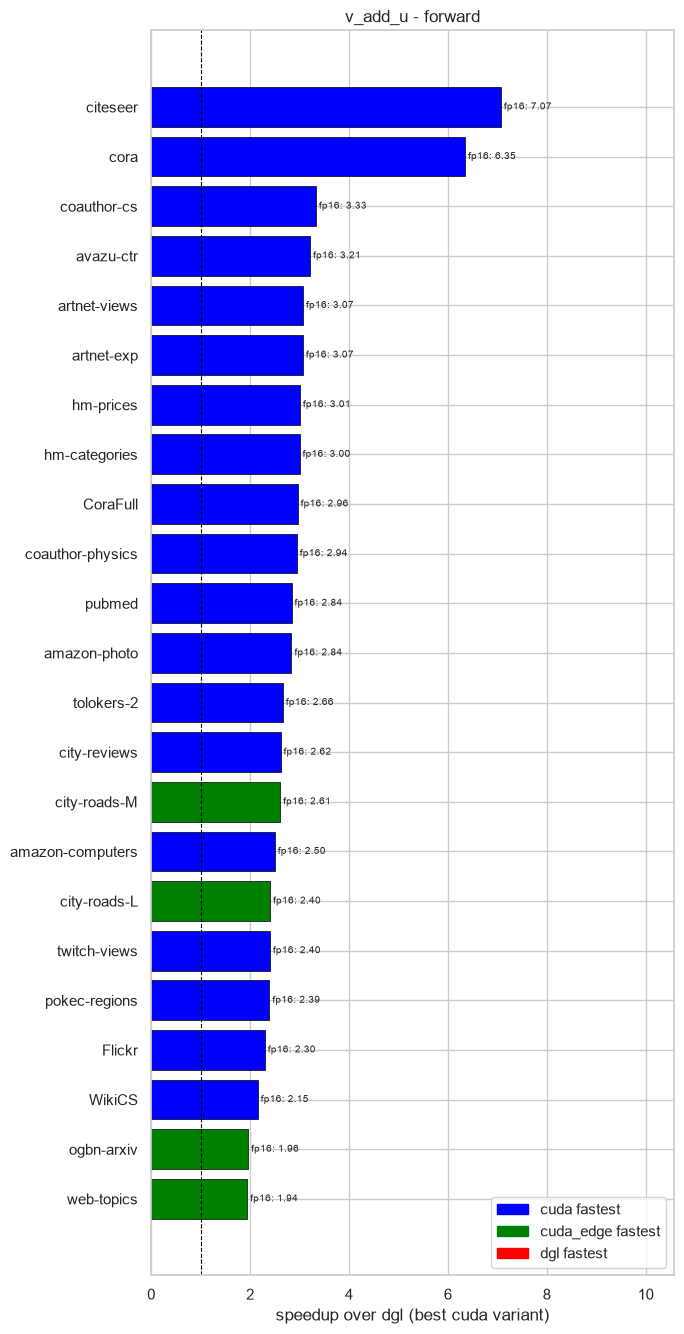

In [ ]:
CONV = "v_add_u"

# best speedup over dgl among the cuda variants (>1 = faster than dgl); inf/0 come from the OOM masking above
df = result.xs(CONV, level="conv_type").reset_index()
df["speedup"] = df[["cuda_speedup", "cuda_edge_speedup"]].max(axis=1)

modes = [m for m in ("forward", "backward") if m in df["mode"].unique()]
# order datasets by their shortest bar (min speedup over dtypes/modes), descending from the top
shortest = df["speedup"].replace(np.inf, np.nan).groupby(df["dataset"]).min()
datasets = shortest.sort_values(ascending=False).index.tolist()
dtypes = sorted(df["dtype"].unique())

bar_h = 0.8 / len(dtypes)
y_base = np.arange(len(datasets))

fig, axes = plt.subplots(1, len(modes), figsize=(7 * len(modes), 0.5 * len(datasets) + 2), sharey=True, squeeze=False)

for ax, mode in zip(axes[0], modes):
    sub = df[df["mode"] == mode]
    finite = sub["speedup"].replace([np.inf, 0.0], np.nan)
    cap = finite.max() * 1.1  # where to draw the "infinitely better" bars

    for j, dtype in enumerate(dtypes):
        d = sub[sub["dtype"] == dtype].set_index("dataset").reindex(datasets)
        y = y_base - 0.4 + bar_h * (j + 0.5)
        vals = d["speedup"].replace(np.inf, cap).fillna(0.0).values
        ax.barh(y, vals, height=bar_h, color=d["color"].fillna("lightgray").values, edgecolor="black", linewidth=0.5)
        for yi, v, raw in zip(y, vals, d["speedup"].values):
            label = "∞" if np.isinf(raw) else ("OOM" if raw == 0.0 or np.isnan(raw) else f"{raw:.2f}")
            ax.text(v, yi, f" {dtype}: {label}", va="center", ha="left", fontsize=7)

    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
    ax.set_yticks(y_base)
    ax.set_yticklabels(datasets)
    ax.invert_yaxis()  # first (largest min-speedup) dataset on top
    ax.set_xlim(0, cap * 1.1)
    ax.set_xlabel("speedup over dgl (best cuda variant)")
    ax.set_title(f"{CONV} - {mode}")

handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=f"{b} fastest") for b, c in BACKEND_COLORS.items()]
axes[0][0].legend(handles=handles, loc="lower right")
fig.tight_layout()
plt.show()


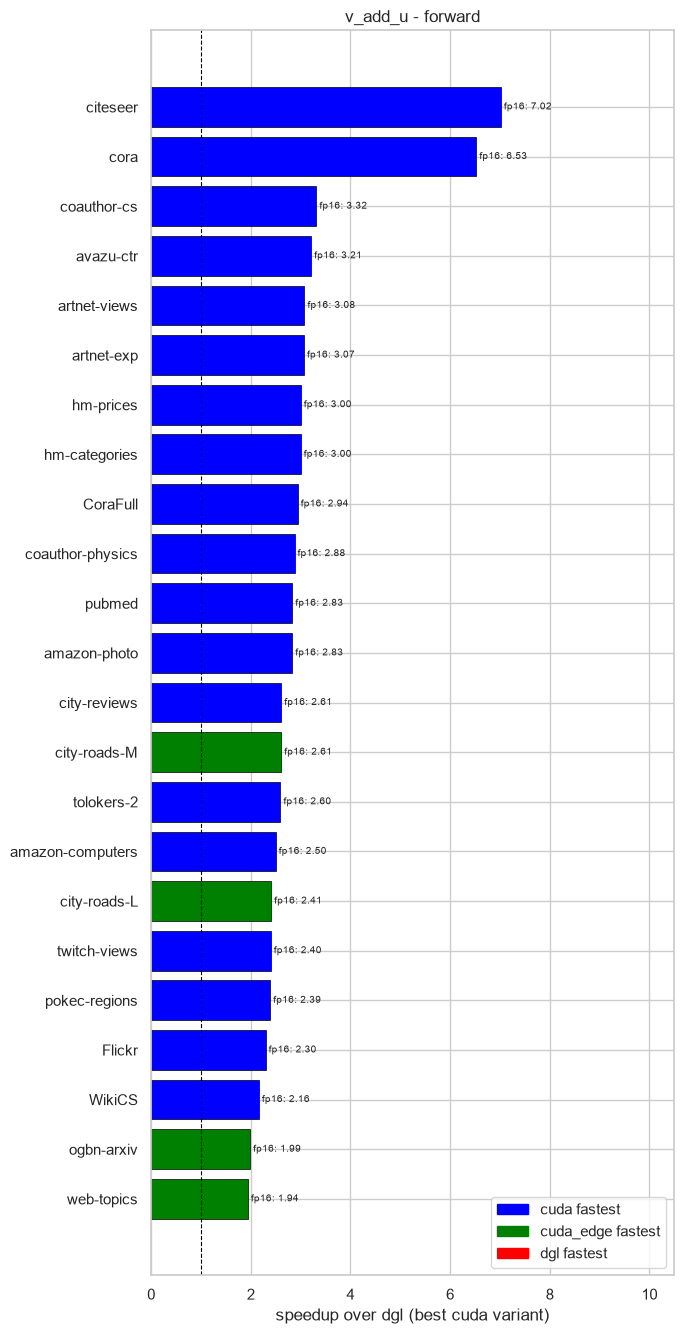

In [ ]:
CONV = "v_add_u"

# best speedup over dgl among the cuda variants (>1 = faster than dgl); inf/0 come from the OOM masking above
df = result.xs(CONV, level="conv_type").reset_index()
df["speedup"] = df[["cuda_speedup", "cuda_edge_speedup"]].max(axis=1)

modes = [m for m in ("forward", "backward") if m in df["mode"].unique()]
# order datasets by their shortest bar (min speedup over dtypes/modes), descending from the top
shortest = df["speedup"].replace(np.inf, np.nan).groupby(df["dataset"]).min()
datasets = shortest.sort_values(ascending=False).index.tolist()
dtypes = sorted(df["dtype"].unique())

bar_h = 0.8 / len(dtypes)
y_base = np.arange(len(datasets))

fig, axes = plt.subplots(1, len(modes), figsize=(7 * len(modes), 0.5 * len(datasets) + 2), sharey=True, squeeze=False)

for ax, mode in zip(axes[0], modes):
    sub = df[df["mode"] == mode]
    finite = sub["speedup"].replace([np.inf, 0.0], np.nan)
    cap = finite.max() * 1.1  # where to draw the "infinitely better" bars

    for j, dtype in enumerate(dtypes):
        d = sub[sub["dtype"] == dtype].set_index("dataset").reindex(datasets)
        y = y_base - 0.4 + bar_h * (j + 0.5)
        vals = d["speedup"].replace(np.inf, cap).fillna(0.0).values
        ax.barh(y, vals, height=bar_h, color=d["color"].fillna("lightgray").values, edgecolor="black", linewidth=0.5)
        for yi, v, raw in zip(y, vals, d["speedup"].values):
            label = "∞" if np.isinf(raw) else ("OOM" if raw == 0.0 or np.isnan(raw) else f"{raw:.2f}")
            ax.text(v, yi, f" {dtype}: {label}", va="center", ha="left", fontsize=7)

    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
    ax.set_yticks(y_base)
    ax.set_yticklabels(datasets)
    ax.invert_yaxis()  # first (largest min-speedup) dataset on top
    ax.set_xlim(0, cap * 1.1)
    ax.set_xlabel("speedup over dgl (best cuda variant)")
    ax.set_title(f"{CONV} - {mode}")

handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=f"{b} fastest") for b, c in BACKEND_COLORS.items()]
axes[0][0].legend(handles=handles, loc="lower right")
fig.tight_layout()
plt.show()


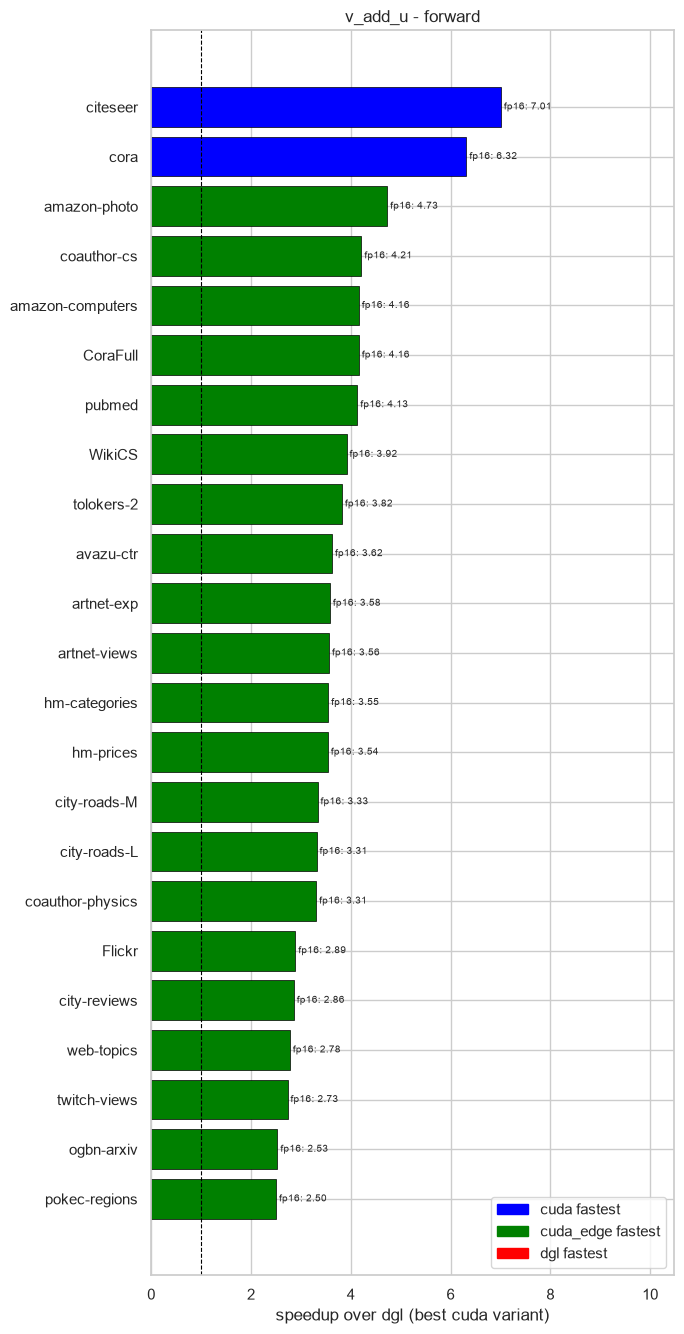

In [ ]:
CONV = "v_add_u"

# best speedup over dgl among the cuda variants (>1 = faster than dgl); inf/0 come from the OOM masking above
df = result.xs(CONV, level="conv_type").reset_index()
df["speedup"] = df[["cuda_speedup", "cuda_edge_speedup"]].max(axis=1)

modes = [m for m in ("forward", "backward") if m in df["mode"].unique()]
# order datasets by their shortest bar (min speedup over dtypes/modes), descending from the top
shortest = df["speedup"].replace(np.inf, np.nan).groupby(df["dataset"]).min()
datasets = shortest.sort_values(ascending=False).index.tolist()
dtypes = sorted(df["dtype"].unique())

bar_h = 0.8 / len(dtypes)
y_base = np.arange(len(datasets))

fig, axes = plt.subplots(1, len(modes), figsize=(7 * len(modes), 0.5 * len(datasets) + 2), sharey=True, squeeze=False)

for ax, mode in zip(axes[0], modes):
    sub = df[df["mode"] == mode]
    finite = sub["speedup"].replace([np.inf, 0.0], np.nan)
    cap = finite.max() * 1.1  # where to draw the "infinitely better" bars

    for j, dtype in enumerate(dtypes):
        d = sub[sub["dtype"] == dtype].set_index("dataset").reindex(datasets)
        y = y_base - 0.4 + bar_h * (j + 0.5)
        vals = d["speedup"].replace(np.inf, cap).fillna(0.0).values
        ax.barh(y, vals, height=bar_h, color=d["color"].fillna("lightgray").values, edgecolor="black", linewidth=0.5)
        for yi, v, raw in zip(y, vals, d["speedup"].values):
            label = "∞" if np.isinf(raw) else ("OOM" if raw == 0.0 or np.isnan(raw) else f"{raw:.2f}")
            ax.text(v, yi, f" {dtype}: {label}", va="center", ha="left", fontsize=7)

    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
    ax.set_yticks(y_base)
    ax.set_yticklabels(datasets)
    ax.invert_yaxis()  # first (largest min-speedup) dataset on top
    ax.set_xlim(0, cap * 1.1)
    ax.set_xlabel("speedup over dgl (best cuda variant)")
    ax.set_title(f"{CONV} - {mode}")

handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=f"{b} fastest") for b, c in BACKEND_COLORS.items()]
axes[0][0].legend(handles=handles, loc="lower right")
fig.tight_layout()
plt.show()


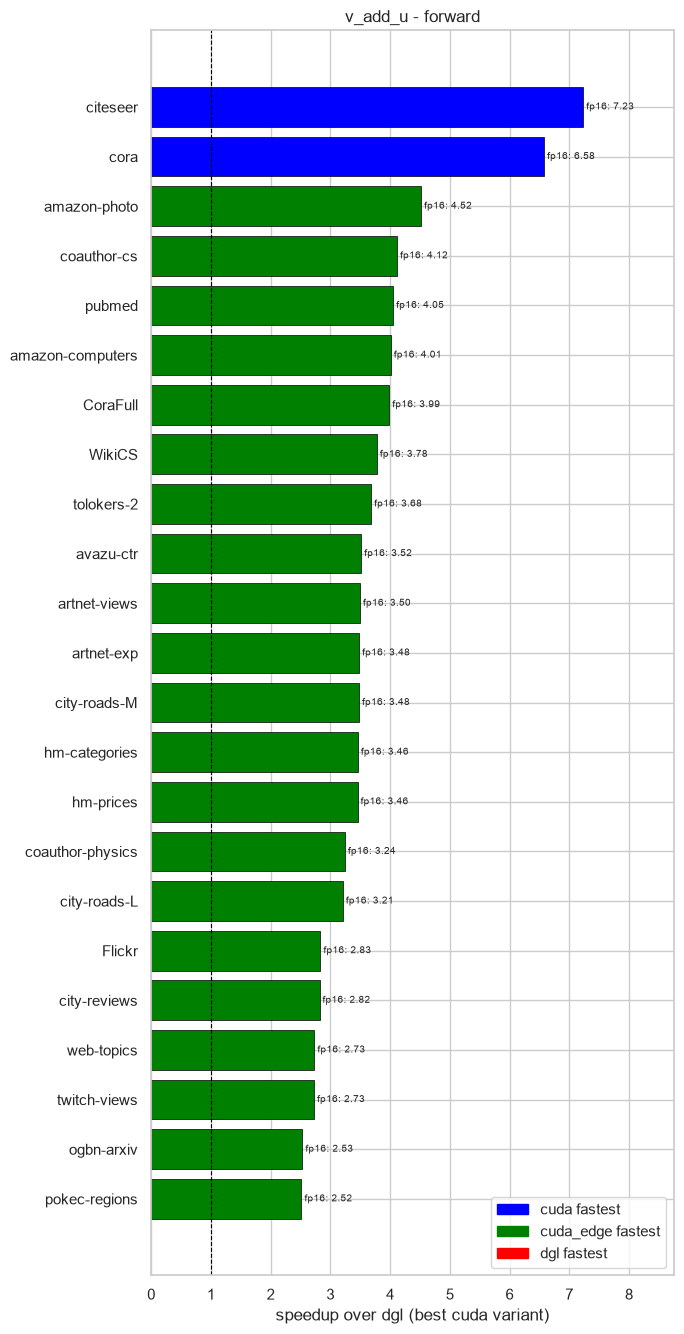

In [30]:
CONV = "v_add_u"

# best speedup over dgl among the cuda variants (>1 = faster than dgl); inf/0 come from the OOM masking above
df = result.xs(CONV, level="conv_type").reset_index()
df["speedup"] = df[["cuda_speedup", "cuda_edge_speedup"]].max(axis=1)

modes = [m for m in ("forward", "backward") if m in df["mode"].unique()]
# order datasets by their shortest bar (min speedup over dtypes/modes), descending from the top
shortest = df["speedup"].replace(np.inf, np.nan).groupby(df["dataset"]).min()
datasets = shortest.sort_values(ascending=False).index.tolist()
dtypes = sorted(df["dtype"].unique())

bar_h = 0.8 / len(dtypes)
y_base = np.arange(len(datasets))

fig, axes = plt.subplots(1, len(modes), figsize=(7 * len(modes), 0.5 * len(datasets) + 2), sharey=True, squeeze=False)

for ax, mode in zip(axes[0], modes):
    sub = df[df["mode"] == mode]
    finite = sub["speedup"].replace([np.inf, 0.0], np.nan)
    cap = finite.max() * 1.1  # where to draw the "infinitely better" bars

    for j, dtype in enumerate(dtypes):
        d = sub[sub["dtype"] == dtype].set_index("dataset").reindex(datasets)
        y = y_base - 0.4 + bar_h * (j + 0.5)
        vals = d["speedup"].replace(np.inf, cap).fillna(0.0).values
        ax.barh(y, vals, height=bar_h, color=d["color"].fillna("lightgray").values, edgecolor="black", linewidth=0.5)
        for yi, v, raw in zip(y, vals, d["speedup"].values):
            label = "∞" if np.isinf(raw) else ("OOM" if raw == 0.0 or np.isnan(raw) else f"{raw:.2f}")
            ax.text(v, yi, f" {dtype}: {label}", va="center", ha="left", fontsize=7)

    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
    ax.set_yticks(y_base)
    ax.set_yticklabels(datasets)
    ax.invert_yaxis()  # first (largest min-speedup) dataset on top
    ax.set_xlim(0, cap * 1.1)
    ax.set_xlabel("speedup over dgl (best cuda variant)")
    ax.set_title(f"{CONV} - {mode}")

handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=f"{b} fastest") for b, c in BACKEND_COLORS.items()]
axes[0][0].legend(handles=handles, loc="lower right")
fig.tight_layout()
plt.show()
